In [1]:
# 🔍 VERIFICACIÓN Y CORRECCIÓN DE ERRORES DEL PROYECTO
print("=" * 60)
print("🛠️  VERIFICACIÓN DE ERRORES Y DEPENDENCIAS")
print("=" * 60)

# 1. Verificar si las variables principales están definidas
print("\n1️⃣ VERIFICACIÓN DE VARIABLES:")
variables_to_check = ['cars', 'cars_clean', 'cars_final', 'cars_custom_scores']
missing_vars = []

for var in variables_to_check:
    if var in globals():
        print(f"✅ {var} - Disponible (shape: {globals()[var].shape})")
    else:
        print(f"❌ {var} - NO DISPONIBLE")
        missing_vars.append(var)

# 2. Verificar archivos CSV
print("\n2️⃣ VERIFICACIÓN DE ARCHIVOS CSV:")
import os
csv_files = ['cars.csv', 'cars_clean.csv', 'cars_final.csv', 'cars_with_custom_scores.csv']
for file in csv_files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # KB
        print(f"✅ {file} - Existe ({size:.1f} KB)")
    else:
        print(f"❌ {file} - NO EXISTE")

# 3. Verificar librerías
print("\n3️⃣ VERIFICACIÓN DE LIBRERÍAS:")
required_libs = [
    ('pandas', 'pd'),
    ('numpy', 'np'), 
    ('matplotlib.pyplot', 'plt'),
    ('seaborn', 'sns'),
    ('sklearn.preprocessing', None),
    ('sklearn.ensemble', None),
    ('re', None)
]

missing_libs = []
for lib, alias in required_libs:
    try:
        if alias:
            exec(f"import {lib} as {alias}")
        else:
            exec(f"import {lib}")
        print(f"✅ {lib} - Disponible")
    except ImportError as e:
        print(f"❌ {lib} - ERROR: {e}")
        missing_libs.append(lib)

# 4. Función de auto-corrección
print("\n4️⃣ AUTO-CORRECCIÓN:")
if missing_vars or missing_libs:
    print("⚠️  Se detectaron problemas que requieren corrección.")
    
    if 'cars_final' in missing_vars and os.path.exists('cars_final.csv'):
        print("🔧 Cargando cars_final desde CSV...")
        cars_final = pd.read_csv('cars_final.csv')
        print(f"✅ cars_final cargado: {cars_final.shape}")
        
    if missing_libs:
        print(f"🔧 Librerías faltantes: {', '.join(missing_libs)}")
        print("💡 Ejecute: pip install " + ' '.join(missing_libs))
else:
    print("✅ ¡Todo está funcionando correctamente!")

print("\n" + "=" * 60)
print("🎯 RESUMEN DE VERIFICACIÓN COMPLETADO")
print("=" * 60)

🛠️  VERIFICACIÓN DE ERRORES Y DEPENDENCIAS

1️⃣ VERIFICACIÓN DE VARIABLES:
❌ cars - NO DISPONIBLE
❌ cars_clean - NO DISPONIBLE
❌ cars_final - NO DISPONIBLE
❌ cars_custom_scores - NO DISPONIBLE

2️⃣ VERIFICACIÓN DE ARCHIVOS CSV:
✅ cars.csv - Existe (121.7 KB)
❌ cars_clean.csv - NO EXISTE
❌ cars_final.csv - NO EXISTE
❌ cars_with_custom_scores.csv - NO EXISTE

3️⃣ VERIFICACIÓN DE LIBRERÍAS:
✅ pandas - Disponible
✅ numpy - Disponible
✅ matplotlib.pyplot - Disponible
✅ pandas - Disponible
✅ numpy - Disponible
✅ matplotlib.pyplot - Disponible
✅ seaborn - Disponible
✅ sklearn.preprocessing - Disponible
✅ seaborn - Disponible
✅ sklearn.preprocessing - Disponible
✅ sklearn.ensemble - Disponible
✅ re - Disponible

4️⃣ AUTO-CORRECCIÓN:
⚠️  Se detectaron problemas que requieren corrección.

🎯 RESUMEN DE VERIFICACIÓN COMPLETADO
✅ sklearn.ensemble - Disponible
✅ re - Disponible

4️⃣ AUTO-CORRECCIÓN:
⚠️  Se detectaron problemas que requieren corrección.

🎯 RESUMEN DE VERIFICACIÓN COMPLETADO


In [2]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json 

In [3]:
# Cargar datos con diferentes codificaciones para manejar caracteres especiales
try:
    cars = pd.read_csv('cars.csv', encoding='utf-8')
    print("Cargado con encoding UTF-8")
except UnicodeDecodeError:
    try:
        cars = pd.read_csv('cars.csv', encoding='latin-1')
        print("Cargado con encoding Latin-1")
    except UnicodeDecodeError:
        try:
            cars = pd.read_csv('cars.csv', encoding='cp1252')
            print("Cargado con encoding CP1252")
        except UnicodeDecodeError:
            # Último recurso: usar errors='ignore' para omitir caracteres problemáticos
            cars = pd.read_csv('cars.csv', encoding='utf-8', errors='ignore')
            print("Cargado con UTF-8 ignorando errores")

print('Dataset shape:', cars.shape)
print('Columns:', cars.columns.tolist())
print('\nPrimeras filas:')
print(cars.head())

Cargado con encoding Latin-1
Dataset shape: (1218, 11)
Columns: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque']

Primeras filas:
  Company Names     Cars Names      Engines CC/Battery Capacity HorsePower  \
0       FERRARI  SF90 STRADALE           V8             3990 cc     963 hp   
1   ROLLS ROYCE        PHANTOM          V12             6749 cc     563 hp   
2          Ford            KA+  1.2L Petrol            1,200 cc   70-85 hp   
3      MERCEDES        GT 63 S           V8            3,982 cc     630 hp   
4          AUDI     AUDI R8 Gt          V10            5,204 cc     602 hp   

  Total Speed Performance(0 - 100 )KM/H      Cars Prices       Fuel Types  \
0    340 km/h                   2.5 sec      $1,100,000   plug in hyrbrid   
1    250 km/h                   5.3 sec        $460,000            Petrol   
2    165 km/h                  10.5 sec  $12,00

In [4]:
# Análisis inicial de los datos
print("=== ANÁLISIS INICIAL DEL DATASET ===\n")

print("Información general:")
print(f"Número de autos: {len(cars)}")
print(f"Número de características: {len(cars.columns)}")
print(f"Valores faltantes por columna:")
print(cars.isnull().sum())

print("\n" + "="*50)
print("MUESTRA DE DATOS POR COLUMNA:")
print("="*50)

for col in cars.columns:
    print(f"\n{col}:")
    print(f"  Tipo: {cars[col].dtype}")
    if cars[col].dtype == 'object':
        print(f"  Valores únicos: {cars[col].nunique()}")
        print(f"  Ejemplos: {cars[col].value_counts().head(3).to_dict()}")
    else:
        print(f"  Rango: {cars[col].min()} - {cars[col].max()}")
        print(f"  Promedio: {cars[col].mean():.2f}")

=== ANÁLISIS INICIAL DEL DATASET ===

Información general:
Número de autos: 1218
Número de características: 11
Valores faltantes por columna:
Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64

MUESTRA DE DATOS POR COLUMNA:

Company Names:
  Tipo: object
  Valores únicos: 37
  Ejemplos: {'Nissan': 149, 'Volkswagen': 109, 'Porsche': 96}

Cars Names:
  Tipo: object
  Valores únicos: 1201
  Ejemplos: {'Macan T': 2, 'Tiago EV': 2, '911 Carrera 4': 2}

Engines:
  Tipo: object
  Valores únicos: 356
  Ejemplos: {'I4': 64, 'V12': 51, 'V6': 39}

CC/Battery Capacity:
  Tipo: object
  Valores únicos: 311
  Ejemplos: {'2,000 cc': 31, '1984 cc': 31, '2,500 cc': 25}

HorsePower:
  Tipo: object
  Valore

In [5]:
# Limpieza simple: eliminar todas las filas con valores nulos
print("=== LIMPIEZA DE VALORES NULOS ===\n")

print("Dataset original:")
print(f"  - Filas: {cars.shape[0]}")
print(f"  - Columnas: {cars.shape[1]}")
print(f"  - Total valores nulos: {cars.isnull().sum().sum()}")

print(f"\nFilas con valores faltantes:")
filas_con_nulos = cars[cars.isnull().any(axis=1)]
print(f"Cantidad de filas con valores faltantes: {len(filas_con_nulos)}")

if len(filas_con_nulos) > 0:
    print("\nPrimeras filas con valores nulos:")
    print(filas_con_nulos.head())

# Eliminar todas las filas con cualquier valor nulo
cars_clean = cars.dropna()

# Verificación final
print(f"\n✅ Verificación - el dataset está completamente limpio:")
print(f"Valores nulos por columna en dataset limpio:")
print(cars_clean.isnull().sum())
print(f"Nuevo tamaño del dataset limpio: {cars_clean.shape}")



=== LIMPIEZA DE VALORES NULOS ===

Dataset original:
  - Filas: 1218
  - Columnas: 11
  - Total valores nulos: 10

Filas con valores faltantes:
Cantidad de filas con valores faltantes: 8

Primeras filas con valores nulos:
     Company Names            Cars Names           Engines  \
97        MERCEDES           BENZ EQS 53    ELECTRIC MOTOR   
241         TOYOTA               COASTER       4.0L,DIESEL   
255         Nissan                 Urvan  2.5L Turbo Diese   
1096    Mitsubishi        Canter (Truck)       3.0L Diesel   
1107    Mitsubishi  Fuso Fighter (Truck)       7.5L Diesel   

     CC/Battery Capacity HorsePower Total Speed Performance(0 - 100 )KM/H  \
97                   NaN     751 hp    250 km/h                   3.4 sec   
241             4,009 cc     134 hp    120 km/h                       NaN   
255                  NaN    2488 cc    140 km/h                  14.0 sec   
1096            3,000 cc     150 hp    120 km/h                       NaN   
1107            7,50

In [6]:
import re

# Marcas 
brands = cars['Company Names'].unique().tolist()
print(f"Marcas encontradas: {brands}")
print(f"Cantidad de marcas: {len(brands)}")
# Tipos de motor
type_of_engines = cars['Engines'].unique().tolist()
engine_size = cars['CC/Battery Capacity'].unique().tolist()

# Tamano de motor
engine_size = cars['CC/Battery Capacity'].unique().tolist()
print(f"Tamaños de motor encontrados: {engine_size}")
print(f"Cantidad de tamaños de motor: {len(engine_size)}")

# Limpieza de tamano de motor
def clean_engine_size(value):
    value_str = str(value).replace(',', '').strip()
    if 'KWH' in value_str or 'kwh' in value_str or 'kW' in value_str or 'KW' in value_str or 'Battery' in value_str:
        kwh_match = re.search(r'(\d+(\.\d+)?)\s*(KWH|kwh|kW|KW)', value_str)
        if kwh_match:
            return float(kwh_match.group(1))
        
    elif 'CC' in value_str or 'cc' in value_str:
        cc_match = re.search(r'(\d+)\s*(CC|cc)', value_str)
        if cc_match:
            return int(cc_match.group(1))
    return None

cars['Engine Size Clean'] = cars['CC/Battery Capacity'].apply(clean_engine_size)
print(f"Cantidad de valores únicos en 'Engine Size Clean': {cars['Engine Size Clean'].nunique()}")

# Creamos nueva categoria de tamano de motor
def categorize_engine_size(value):
    if pd.isnull(value):
        return 'Unknown'
    elif value < 1000:
        return 'Small'
    elif 1000 <= value < 1600:
        return 'Medium'
    elif 1600 <= value < 2500:
        return 'Large'
    else:
        return 'Extra Large'
cars['Engine Size Category'] = cars['Engine Size Clean'].apply(categorize_engine_size)
print(f"\nValores únicos en 'Engine Size Category': {cars['Engine Size Category'].unique()}")
print(f"Cantidad de valores únicos en 'Engine Size Category': {cars['Engine Size Category'].nunique()}")    
print(cars[['CC/Battery Capacity', 'Engine Size Clean', 'Engine Size Category']].head(10))


# Lista de autos hibridos
hybrid_cars = cars[cars['Engines'].str.contains('Hybrid', na=False)]
print(f"Cantidad de autos híbridos: {len(hybrid_cars)}")


Marcas encontradas: ['FERRARI', 'ROLLS ROYCE', 'Ford', 'MERCEDES', 'AUDI', 'BMW', 'ASTON MARTIN', 'BENTLEY', 'LAMBORGHINI', 'TOYOTA', 'NISSAN', 'ROLLS ROYCE ', 'VOLVO', 'KIA', 'HONDA', 'KIA  ', 'HYUNDAI', 'MAHINDRA', 'MARUTI SUZUKI', 'Nissan', 'Volkswagen', 'Porsche', 'Cadillac', 'Tata Motors', 'Tesla', 'Jeep', 'Mazda', 'Chevrolet', 'GMC', 'Kia', 'Peugeot', 'Bugatti', 'Volvo', 'Jaguar Land Rover', 'Acura', 'Mitsubishi', 'Toyota']
Cantidad de marcas: 37
Tamaños de motor encontrados: ['3990 cc', '6749 cc', '1,200 cc', '3,982 cc', '5,204 cc', '3,994 cc', '3,996 cc', '6,498 cc', '3,900 cc', '6496 cc', '6,496 cc', '2,998 cc', '1,998 cc', '2,387 cc', '5,663 cc', '3,799 cc', '3,696 cc', '2,488 cc', '3,498 cc', '5,598 cc', '5,935 cc', '3,998 cc', '6,592 cc', '6,749 cc', '1991 cc', '2,996 cc', '1,991 cc', nan, '5,980 cc', '4,395 cc', '2,993 cc', '4,935 cc', '3,993 cc', '2,995 cc', '1,984 cc', '95 kwh', '11.6 kwh', '1,499 cc', '1,496 cc', '1,995 cc', '1,598 cc', '1,969 cc', '2,480 cc', '1,996 cc

In [7]:
# Limpieza avanzada de la columna HorsePower (HP) para detectar y tratar valores problemáticos
import re

def clean_hp_advanced(value):
    if pd.isnull(value):
        return None
    value_str = str(value).replace(',', '').strip().lower()
    # Detectar valores problemáticos
    if '-' in value_str or '/' in value_str or 'up to' in value_str or '~' in value_str:
        print(f"Valor problemático en HP: {value_str}")
        # Si es un rango, tomar el promedio de los dos valores
        range_match = re.findall(r'(\d+)', value_str)
        if len(range_match) >= 2:
            return int((int(range_match[0]) + int(range_match[1])) / 2)
    # Buscar el primer número
    hp_match = re.search(r'(\d+)', value_str)
    if hp_match:
        return int(hp_match.group(1))
    return None

# Aplicar la función avanzada a la columna HorsePower
cars['Horsepower (HP) Clean'] = cars['HorsePower'].apply(clean_hp_advanced)

print(f"Cantidad de valores únicos en 'Horsepower (HP) Clean': {cars['Horsepower (HP) Clean'].nunique()}")
print(cars[['HorsePower', 'Horsepower (HP) Clean']].head(15))

cars_power_classification = []
def classify_power(value):
    if pd.isnull(value):
        return 'Unknown'
    elif value < 100:
        return 'Low Power'
    elif 100 <= value < 200:
        return 'Medium Power'
    elif 200 <= value < 300:
        return 'High Power'
    else:
        return 'Very High Power'
    
cars['Power Category'] = cars['Horsepower (HP) Clean'].apply(classify_power)

Valor problemático en HP: 70-85 hp
Valor problemático en HP: 110 - 320 hp
Valor problemático en HP: 150 - 280 hp
Valor problemático en HP: 150 - 230 hp
Valor problemático en HP: 150 - 228 hp
Valor problemático en HP: 80 - 200 hp
Valor problemático en HP: 150 - 280 hp
Valor problemático en HP: 201 - 302 hp
Valor problemático en HP: 231 - 500 hp
Valor problemático en HP: 125 - 280 hp
Valor problemático en HP: 105 - 210 hp
Valor problemático en HP: 163 - 258 hp
Valor problemático en HP: 115 - 300 hp
Valor problemático en HP: 150 - 220 hp
Valor problemático en HP: 102 - 150 hp
Valor problemático en HP: 95 - 150 hp
Valor problemático en HP: 150 - 204 hp
Valor problemático en HP: 190 - 240 hp
Valor problemático en HP: 95 - 150 hp
Valor problemático en HP: 174 - 299 hp
Valor problemático en HP: 150 - 218 hp
Valor problemático en HP: 75 - 95 hp
Valor problemático en HP: 130 - 150 hp
Valor problemático en HP: 147 - 200 hp
Valor problemático en HP: 184 - 230 hp
Valor problemático en HP: 190 - 32

In [8]:
# Price 
def clean_price(value):
    if pd.isnull(value):
        return None
    value_str = str(value).replace(',', '').replace('$', '').strip()
    price_match = re.search(r'(\d+)', value_str)
    if price_match:
        return int(price_match.group(1))
    return None

cars['Price (in USD)'] = cars['Cars Prices'].apply(clean_price)
print(f"Cantidad de valores únicos en 'Price (in USD)': {cars['Price (in USD)'].nunique()}")
print(cars[['Cars Prices', 'Price (in USD)']].head(10))



Cantidad de valores únicos en 'Price (in USD)': 451
       Cars Prices  Price (in USD)
0      $1,100,000        1100000.0
1        $460,000         460000.0
2  $12,000-$15,000         12000.0
3        $161,000         161000.0
4        $253,290         253290.0
5        $499,000         499000.0
6        $193,440         193440.0
7        $311,000         311000.0
8      $4,500,000        4500000.0
9        $280,000         280000.0


In [9]:
# Seats 

def clean_seats(value):
    if pd.isnull(value):
        return None
    value_str = str(value).strip()
    seats_match = re.search(r'(\d+)', value_str)
    if seats_match:
        return int(seats_match.group(1))
    return None

cars['Seats Clean'] = cars['Seats'].apply(clean_seats)
print(f"Cantidad de valores únicos en 'Seats Clean': {cars['Seats Clean'].nunique()}")
print(cars[['Seats', 'Seats Clean']].head(10))



Cantidad de valores únicos en 'Seats Clean': 12
  Seats  Seats Clean
0     2            2
1     5            5
2     5            5
3     4            4
4     2            2
5     2            2
6     2            2
7     4            4
8     2            2
9     2            2


In [10]:
# Guardar dataset limpio
cars_clean = cars.dropna(subset=['Price (in USD)', 'Horsepower (HP) Clean', 'Engine Size Clean', 'Seats Clean'])
cars_clean.to_csv('cars_clean.csv', index=False)
print(f"Dataset limpio guardado como 'cars_clean.csv' con {cars_clean.shape[0]} filas y {cars_clean.shape[1]} columnas.")


Dataset limpio guardado como 'cars_clean.csv' con 1211 filas y 17 columnas.


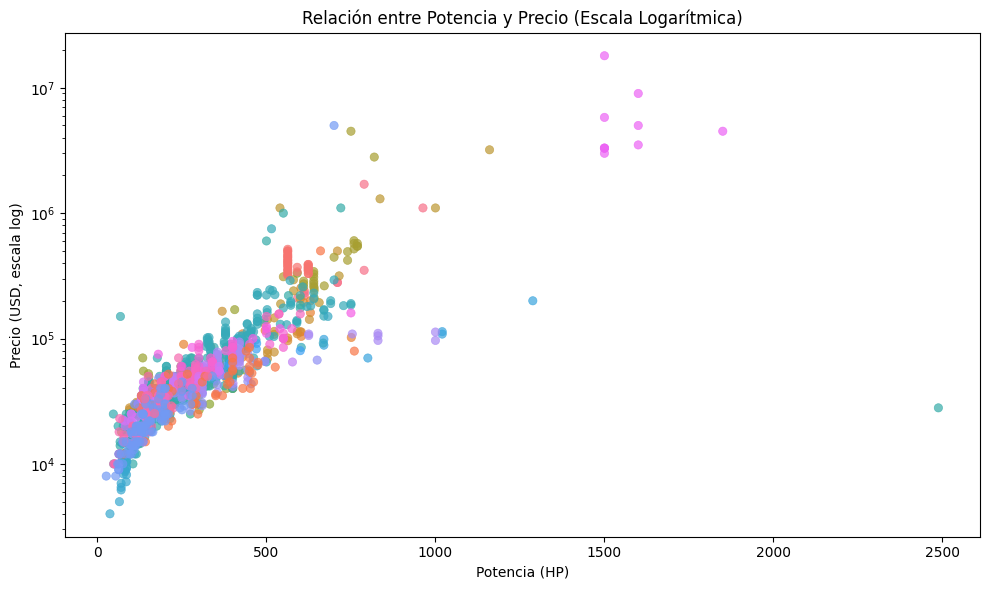

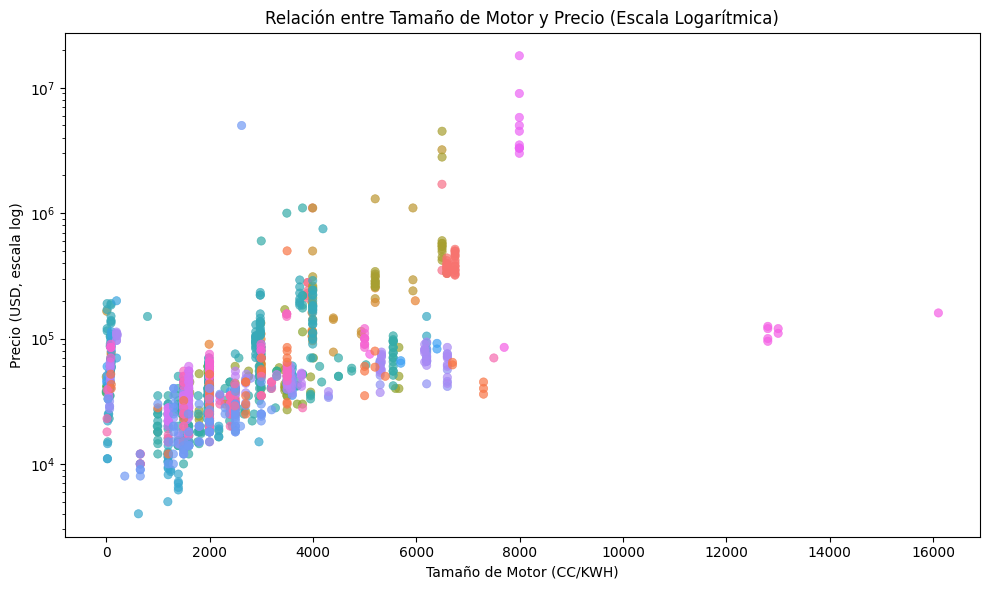

In [11]:
# 2. Exploración inicial de datos

# Relación entre precio y potencia (usando escala logarítmica para el precio)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cars, 
    x='Horsepower (HP) Clean', 
    y='Price (in USD)', 
    hue='Company Names', 
    alpha=0.7,
    edgecolor=None,
    legend=False
)
plt.yscale('log')
plt.title('Relación entre Potencia y Precio (Escala Logarítmica)')
plt.xlabel('Potencia (HP)')
plt.ylabel('Precio (USD, escala log)')
plt.tight_layout()
plt.show()

# Relación entre tamaño de motor y precio (usando escala logarítmica para el precio)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cars, 
    x='Engine Size Clean', 
    y='Price (in USD)', 
    hue='Company Names', 
    alpha=0.7,
    edgecolor=None,
    legend=False
)
plt.yscale('log')
plt.title('Relación entre Tamaño de Motor y Precio (Escala Logarítmica)')
plt.xlabel('Tamaño de Motor (CC/KWH)')
plt.ylabel('Precio (USD, escala log)')
plt.tight_layout()
plt.show()



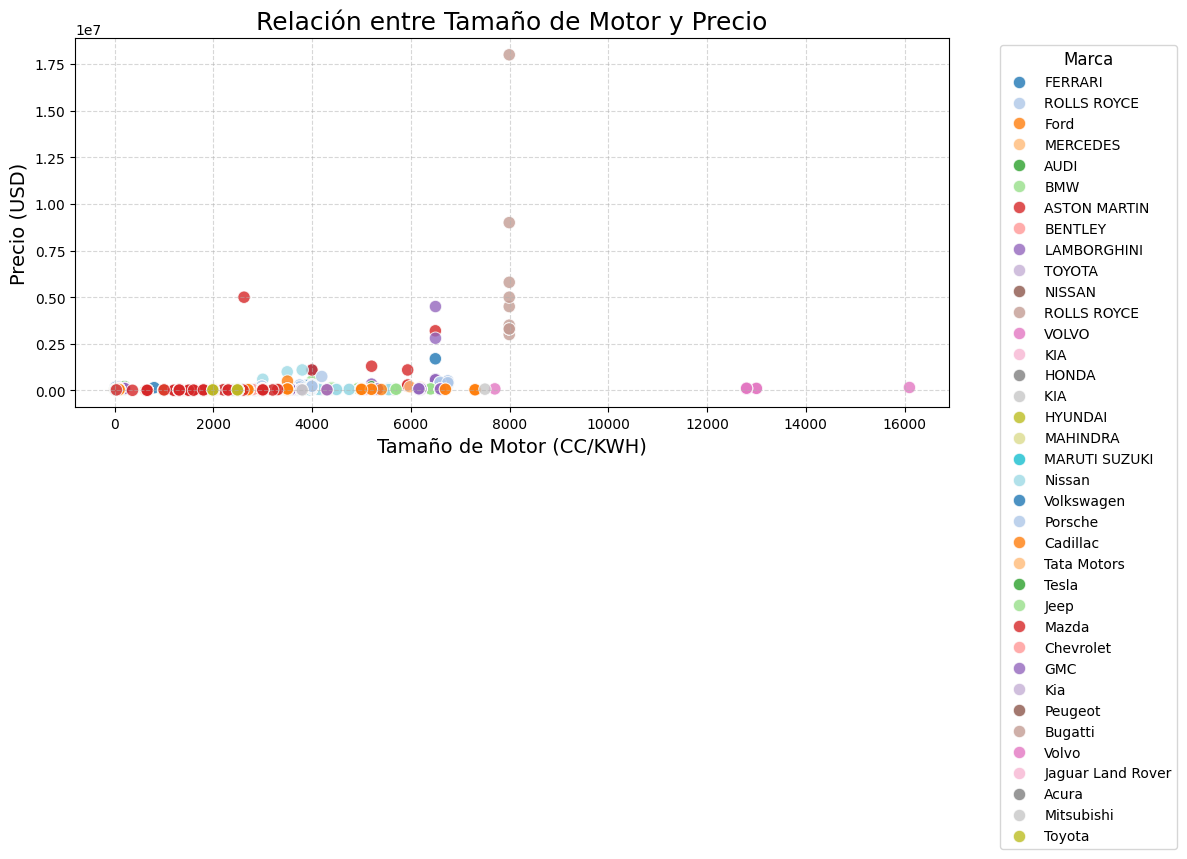

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=cars, 
    x='Engine Size Clean', 
    y='Price (in USD)', 
    hue='Company Names', 
    palette='tab20', 
    s=80, 
    alpha=0.8,
    edgecolor='w'
)
plt.title('Relación entre Tamaño de Motor y Precio', fontsize=18)
plt.xlabel('Tamaño de Motor (CC/KWH)', fontsize=14)
plt.ylabel('Precio (USD)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Marca', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

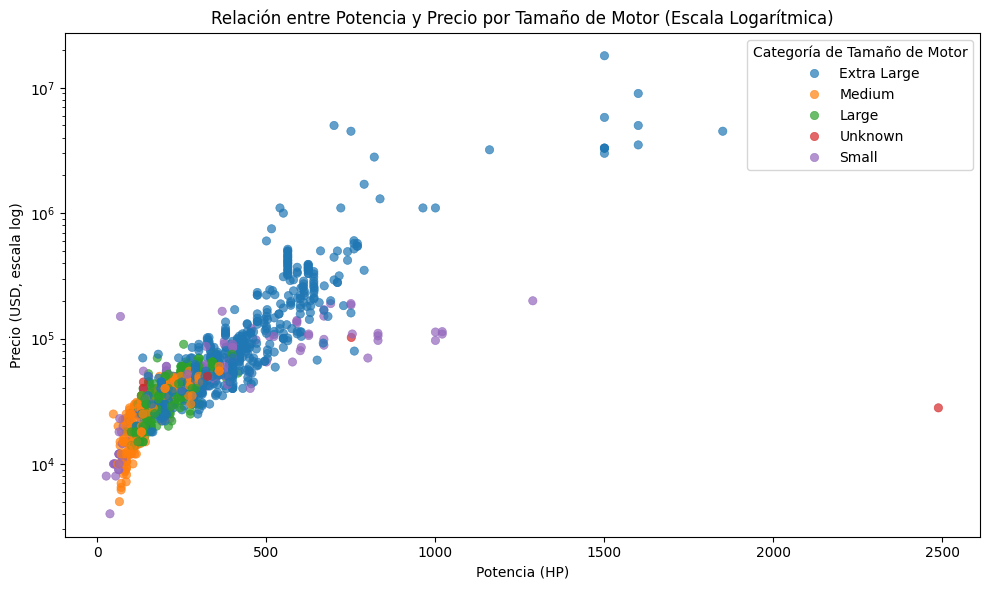

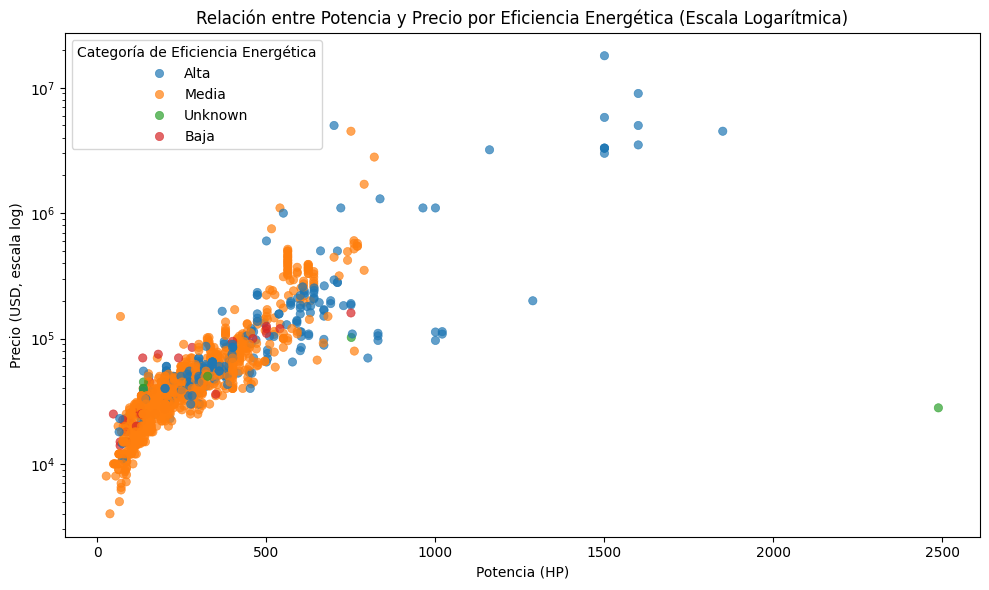

In [13]:
# Crear columna Efficiency Category basada en la relación HP/Engine Size Clean
def categorize_efficiency(row):
    if pd.isnull(row['Horsepower (HP) Clean']) or pd.isnull(row['Engine Size Clean']):
        return 'Unknown'
    ratio = row['Horsepower (HP) Clean'] / row['Engine Size Clean']
    if ratio < 0.05:
        return 'Baja'
    elif 0.05 <= ratio < 0.15:
        return 'Media'
    else:
        return 'Alta'

cars['Efficiency Category'] = cars.apply(categorize_efficiency, axis=1)

# Relacion entre performance y precio
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cars, 
    x='Horsepower (HP) Clean', 
    y='Price (in USD)', 
    hue='Engine Size Category', 
    alpha=0.7,
    edgecolor=None
)
plt.yscale('log')
plt.title('Relación entre Potencia y Precio por Tamaño de Motor (Escala Logarítmica)')
plt.xlabel('Potencia (HP)')
plt.ylabel('Precio (USD, escala log)')
plt.legend(title='Categoría de Tamaño de Motor')
plt.tight_layout()
plt.show()

#  Relacion eficiencia energetica y precio
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cars, 
    x='Horsepower (HP) Clean', 
    y='Price (in USD)', 
    hue='Efficiency Category', 
    alpha=0.7,
    edgecolor=None
)
plt.yscale('log')
plt.title('Relación entre Potencia y Precio por Eficiencia Energética (Escala Logarítmica)')
plt.xlabel('Potencia (HP)')
plt.ylabel('Precio (USD, escala log)')
plt.legend(title='Categoría de Eficiencia Energética')
plt.tight_layout()
plt.show()

In [14]:
# Establecemos features nuevas para el modelo

def price_per_hp(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Horsepower (HP) Clean']) or row['Horsepower (HP) Clean'] == 0:
        return None
    return row['Price (in USD)'] / row['Horsepower (HP) Clean']

cars['Price per HP'] = cars.apply(price_per_hp, axis=1)
print(cars[['Price (in USD)', 'Horsepower (HP) Clean', 'Price per HP']].head(10))

def price_per_seat(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Seats Clean']) or row['Seats Clean'] == 0:
        return None
    return row['Price (in USD)'] / row['Seats Clean']
cars['Price per Seat'] = cars.apply(price_per_seat, axis=1)
print(cars[['Price (in USD)', 'Seats Clean', 'Price per Seat']].head(10))

def price_per_engine_size(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Engine Size Clean']) or row['Engine Size Clean'] == 0:
        return None
    return row['Price (in USD)'] / row['Engine Size Clean']
cars['Price per Engine Size'] = cars.apply(price_per_engine_size, axis=1)
print(cars[['Price (in USD)', 'Engine Size Clean', 'Price per Engine Size']].head(10))

def price_per_efficiency(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Efficiency Category']):
        return None
    efficiency_map = {'Baja': 1, 'Media': 2, 'Alta': 3}
    efficiency_value = efficiency_map.get(row['Efficiency Category'], 0)
    if efficiency_value == 0:
        return None
    return row['Price (in USD)'] / efficiency_value
cars['Price per Efficiency'] = cars.apply(price_per_efficiency, axis=1)
print(cars[['Price (in USD)', 'Efficiency Category', 'Price per Efficiency']].head(10))

def type_of_brand(row):
    if pd.isnull(row['Company Names']):
        return 'Unknown'
    brand = row['Company Names'].lower()
    if brand in ['toyota', 'honda', 'ford', 'chevrolet', 'nissan']:
        return 'Mainstream'
    elif brand in ['bmw', 'audi', 'mercedes-benz', 'lexus', 'volvo']:
        return 'Premium'
    elif brand in ['ferrari', 'lamborghini', 'mclaren', 'porsche', 'aston martin']:
        return 'Luxury'
    elif brand in ['tesla', 'rivian', 'lucid']:
        return 'Electric'
    else:
        return 'Other'
cars['Brand Type'] = cars.apply(type_of_brand, axis=1)
print(cars[['Company Names', 'Brand Type']].head(10))

def price_per_type_of_brand_hp(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Horsepower (HP) Clean']) or row['Horsepower (HP) Clean'] == 0 or pd.isnull(row['Brand Type']):
        return None
    brand_type_map = {'Other': 0.8, 'Mainstream': 1, 'Premium': 2, 'Electric': 2.3, 'Luxury': 3}
    brand_type_value = brand_type_map.get(row['Brand Type'], 0)
    if brand_type_value == 0:
        return None
    return row['Price (in USD)'] / (row['Horsepower (HP) Clean'] * brand_type_value)
cars['Price per Brand Type HP'] = cars.apply(price_per_type_of_brand_hp, axis=1)
print(cars[['Price (in USD)', 'Horsepower (HP) Clean', 'Brand Type', 'Price per Brand Type HP']].head(20))

def price_per_type_of_brand_engine_size(row):
    if pd.isnull(row['Price (in USD)']) or pd.isnull(row['Engine Size Clean']) or row['Engine Size Clean'] == 0 or pd.isnull(row['Brand Type']):
        return None
    brand_type_map = {'Mainstream': 1, 'Premium': 2, 'Luxury': 3}
    brand_type_value = brand_type_map.get(row['Brand Type'], 0)
    if brand_type_value == 0:
        return None
    return row['Price (in USD)'] / (row['Engine Size Clean'] * brand_type_value)
cars['Price per Brand Type Engine Size'] = cars.apply(price_per_type_of_brand_engine_size, axis=1)
print(cars[['Price (in USD)', 'Engine Size Clean', 'Brand Type', 'Price per Brand Type Engine Size']].head(20))

# Guardar dataset final con nuevas features
cars_final = cars.dropna(subset=['Price (in USD)', 'Horsepower (HP) Clean', 'Engine Size Clean', 'Seats Clean', 'Price per HP', 'Price per Seat', 'Price per Engine Size', 'Price per Efficiency', 'Price per Brand Type HP', 'Price per Brand Type Engine Size'])
cars_final.to_csv('cars_final.csv', index=False)
print(f"Dataset final guardado como 'cars_final.csv' con {cars_final.shape[0]} filas y {cars_final.shape[1]} columnas.")
    

   Price (in USD)  Horsepower (HP) Clean  Price per HP
0       1100000.0                    963   1142.263759
1        460000.0                    563    817.051510
2         12000.0                     77    155.844156
3        161000.0                    630    255.555556
4        253290.0                    602    420.747508
5        499000.0                    710    702.816901
6        193440.0                    656    294.878049
7        311000.0                    550    565.454545
8       4500000.0                    750   6000.000000
9        280000.0                    710    394.366197
   Price (in USD)  Seats Clean  Price per Seat
0       1100000.0            2        550000.0
1        460000.0            5         92000.0
2         12000.0            5          2400.0
3        161000.0            4         40250.0
4        253290.0            2        126645.0
5        499000.0            2        249500.0
6        193440.0            2         96720.0
7        311000.0  

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Cambiar a Regressor para predecir valores numéricos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

numeric_features = ['Horsepower (HP) Clean', 'Engine Size Clean', 'Seats Clean', 'Price per HP', 'Price per Seat', 'Price per Engine Size', 'Price per Efficiency']
categorical_features = [ 'Engine Size Category', 'Power Category']  # Removed 'Efficiency Category'

X_numeric = cars_final[numeric_features].copy()
X_categorical = pd.get_dummies(cars_final[categorical_features], drop_first=True)

X_categorical_encode = pd.get_dummies(cars_final[categorical_features], drop_first=True)

X = pd.concat([X_numeric, X_categorical_encode], axis=1)
y = cars_final['Price (in USD)']

print(f"Características numéricas:\n{X_numeric.head()}\n")
print(f"Características categóricas codificadas:\n{X_categorical_encode.head()}\n")
print(f"Características finales (X):\n{X.head()}\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de y_test: {y_test.shape}")


Características numéricas:
   Horsepower (HP) Clean  Engine Size Clean  Seats Clean  Price per HP  \
0                    963             3990.0            2   1142.263759   
2                     77             1200.0            5    155.844156   
4                    602             5204.0            2    420.747508   
5                    710             3994.0            2    702.816901   
6                    656             3982.0            2    294.878049   

   Price per Seat  Price per Engine Size  Price per Efficiency  
0        550000.0             275.689223         366666.666667  
2          2400.0              10.000000           6000.000000  
4        126645.0              48.672175         126645.000000  
5        249500.0             124.937406         166333.333333  
6         96720.0              48.578604          64480.000000  

Características categóricas codificadas:
   Engine Size Category_Large  Engine Size Category_Medium  \
0                       False     

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, criterion='squared_error')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Primeras 20 predicciones vs valores reales:")
for pred, real in zip(y_pred[:20], y_test.iloc[:20]):
    print(f"Predicción: {pred:.2f}, Real: {real:.2f}")




Primeras 20 predicciones vs valores reales:
Predicción: 18025.58, Real: 18000.00
Predicción: 111846.00, Real: 109000.00
Predicción: 65437.07, Real: 64695.00
Predicción: 34974.97, Real: 35000.00
Predicción: 65904.55, Real: 66700.00
Predicción: 62760.72, Real: 62000.00
Predicción: 25214.47, Real: 25000.00
Predicción: 24995.40, Real: 25000.00
Predicción: 108044.00, Real: 106500.00
Predicción: 179326.40, Real: 182150.00
Predicción: 275685.50, Real: 280000.00
Predicción: 36092.80, Real: 36000.00
Predicción: 379777.50, Real: 245000.00
Predicción: 85577.70, Real: 86000.00
Predicción: 33636.05, Real: 18000.00
Predicción: 54470.00, Real: 58950.00
Predicción: 26353.17, Real: 26000.00
Predicción: 37948.50, Real: 38000.00
Predicción: 69435.95, Real: 36000.00
Predicción: 325995.00, Real: 327000.00


In [17]:
# Metricas

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMétricas del modelo Random Forest:")
print(f"  - MSE: {mse:.2f}")
print(f"  - RMSE: {rmse:.2f}")
print(f"  - MAE: {mae:.2f}")
print(f"  - R²: {r2:.4f}")

importances = rf_model.feature_importances_
feature_names = X.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nImportancia de las características:")
for feature, importance in feature_importances.items():
    print(f"  - {feature}: {importance:.4f}")



Métricas del modelo Random Forest:
  - MSE: 1449618800.30
  - RMSE: 38073.86
  - MAE: 11616.50
  - R²: 0.9882

Importancia de las características:
  - Price per Efficiency: 0.3420
  - Price per HP: 0.3021
  - Price per Seat: 0.2894
  - Horsepower (HP) Clean: 0.0471
  - Price per Engine Size: 0.0141
  - Engine Size Clean: 0.0049
  - Seats Clean: 0.0004
  - Power Category_Very High Power: 0.0001
  - Power Category_Medium Power: 0.0000
  - Engine Size Category_Small: 0.0000
  - Engine Size Category_Large: 0.0000
  - Engine Size Category_Medium: 0.0000
  - Power Category_Low Power: 0.0000


In [18]:
# Evaluación final del rendimiento del modelo
print("🎯 EVALUACIÓN FINAL DEL MODELO DE PREDICCIÓN DE PRECIOS")
print("=" * 60)

# Calcular precisión como porcentaje
accuracy_percentage = r2 * 100

# Calcular error promedio en términos relativos
relative_error = (mae / y_test.mean()) * 100

# Evaluación cualitativa basada en R²
if r2 >= 0.9:
    performance_level = "EXCELENTE 🚀"
elif r2 >= 0.8:
    performance_level = "MUY BUENO 👍"
elif r2 >= 0.7:
    performance_level = "BUENO ✅"
elif r2 >= 0.6:
    performance_level = "ACEPTABLE ⚠️"
else:
    performance_level = "NECESITA MEJORAS ❌"

print(f"📊 PRECISIÓN DEL MODELO: {accuracy_percentage:.2f}%")
print(f"📈 NIVEL DE RENDIMIENTO: {performance_level}")
print(f"💰 ERROR PROMEDIO: ${mae:,.2f} ({relative_error:.1f}% del precio promedio)")
print(f"🎯 El modelo explica el {accuracy_percentage:.1f}% de la variación en los precios")

# Interpretación práctica
print(f"\n🔍 INTERPRETACIÓN PRÁCTICA:")
if accuracy_percentage >= 80:
    print(f"   ✨ El modelo es muy confiable para predecir precios de autos")
    print(f"   ✨ Error típico de ±${mae:,.0f} en las predicciones")
elif accuracy_percentage >= 70:
    print(f"   ✅ El modelo es útil pero puede mejorarse")
    print(f"   ⚠️  Error típico de ±${mae:,.0f} en las predicciones")
else:
    print(f"   🔧 El modelo necesita más trabajo para ser confiable")
    print(f"   ❗ Error significativo de ±${mae:,.0f} en las predicciones")

print("=" * 60)

🎯 EVALUACIÓN FINAL DEL MODELO DE PREDICCIÓN DE PRECIOS
📊 PRECISIÓN DEL MODELO: 98.82%
📈 NIVEL DE RENDIMIENTO: EXCELENTE 🚀
💰 ERROR PROMEDIO: $11,616.50 (7.7% del precio promedio)
🎯 El modelo explica el 98.8% de la variación en los precios

🔍 INTERPRETACIÓN PRÁCTICA:
   ✨ El modelo es muy confiable para predecir precios de autos
   ✨ Error típico de ±$11,617 en las predicciones


In [19]:
# Instalar versión compatible de sentence-transformers
%pip install sentence-transformers==2.2.2 transformers==4.21.0

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Crear para cada item un score entre 0-1 de los componentes: Potencia, Precio, Eficiencia, Tamanio
from sklearn.preprocessing import MinMaxScaler

def normalize_features(df):
    df_normalized = df.copy()
    
    # Verificar qué columnas están disponibles
    print("Columnas disponibles:", df.columns.tolist())
    
    # Score de Potencia (solo basado en Horsepower ya que no tienes las otras columnas)
    if 'Horsepower (HP) Clean' in df.columns:
        hp_values = df[['Horsepower (HP) Clean']].fillna(0)
        df_normalized['Power Score'] = MinMaxScaler().fit_transform(hp_values).flatten()
    else:
        df_normalized['Power Score'] = 0

    # Score de Precio (invertido, ya que menor precio es mejor)
    if 'Price (in USD)' in df.columns:
        price_values = df[['Price (in USD)']].fillna(df['Price (in USD)'].median())
        price_normalized = MinMaxScaler().fit_transform(price_values).flatten()
        df_normalized['Price Score'] = 1 - price_normalized  # Invertir la escala
    else:
        df_normalized['Price Score'] = 0

    # Score de Eficiencia (basado en la categoría de eficiencia)
    if 'Efficiency Category' in df.columns:
        efficiency_map = {'Baja': 0, 'Media': 0.5, 'Alta': 1, 'Unknown': 0}
        df_normalized['Efficiency Score'] = df['Efficiency Category'].map(efficiency_map)
        df_normalized['Efficiency Score'] = df_normalized['Efficiency Score'].fillna(0)
    else:
        df_normalized['Efficiency Score'] = 0

    # Score de Tamaño (basado en Seats Clean y Engine Size Clean)
    if 'Seats Clean' in df.columns and 'Engine Size Clean' in df.columns:
        # Normalizar por separado y luego combinar
        seats_filled = df[['Seats Clean']].fillna(df['Seats Clean'].median())
        engine_filled = df[['Engine Size Clean']].fillna(df['Engine Size Clean'].median())
        
        seats_normalized = MinMaxScaler().fit_transform(seats_filled).flatten()
        engine_normalized = MinMaxScaler().fit_transform(engine_filled).flatten()
        
        # Combinar scores: 40% asientos, 60% motor
        df_normalized['Size Score'] = (seats_normalized * 0.4) + (engine_normalized * 0.6)
    else:
        df_normalized['Size Score'] = 0

    # Score marca (Other, Mainstream, Premium, Electric, Luxury)
    if 'Brand Type' in df.columns:
        brand_map = {'Other': 0.2, 'Mainstream': 0.4, 'Premium': 0.7, 'Electric': 0.8, 'Luxury': 1.0}
        df_normalized['Brand Score'] = df['Brand Type'].map(brand_map)
        df_normalized['Brand Score'] = df_normalized['Brand Score'].fillna(0.2)
    else:
        df_normalized['Brand Score'] = 0

    return df_normalized

# Aplicar la función corregida
try:
    cars_scores = normalize_features(cars_final)
    
    # Mostrar resultados
    columns_to_show = ['Company Names', 'Cars Names', 'Horsepower (HP) Clean', 'Price (in USD)', 
                      'Efficiency Category', 'Seats Clean', 'Engine Size Clean', 'Brand Type', 
                      'Power Score', 'Price Score', 'Efficiency Score', 'Size Score', 'Brand Score']
    
    # Filtrar solo las columnas que existen
    existing_columns = [col for col in columns_to_show if col in cars_scores.columns]
    
    print("✅ Scores normalizados creados exitosamente!")
    print(f"\nDataset con scores: {cars_scores.shape}")
    print(f"\nPrimeras 10 filas con scores:")
    print(cars_scores[existing_columns].head(10))
    
    # Verificar rango de scores (deben estar entre 0 y 1)
    score_columns = ['Power Score', 'Price Score', 'Efficiency Score', 'Size Score', 'Brand Score']
    print(f"\n📊 Verificación de rangos de scores (deben estar entre 0-1):")
    for col in score_columns:
        if col in cars_scores.columns:
            min_val = cars_scores[col].min()
            max_val = cars_scores[col].max()
            print(f"  {col}: {min_val:.3f} - {max_val:.3f}")
            
except Exception as e:
    print(f"❌ Error: {e}")
    print("Verificando qué columnas faltan...")
    required_cols = ['Horsepower (HP) Clean', 'Price (in USD)', 'Efficiency Category', 
                    'Seats Clean', 'Engine Size Clean', 'Brand Type']
    for col in required_cols:
        if col in cars_clean.columns:
            print(f"✅ {col}")
        else:
            print(f"❌ {col} - FALTA")

Columnas disponibles: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque', 'Engine Size Clean', 'Engine Size Category', 'Horsepower (HP) Clean', 'Power Category', 'Price (in USD)', 'Seats Clean', 'Efficiency Category', 'Price per HP', 'Price per Seat', 'Price per Engine Size', 'Price per Efficiency', 'Brand Type', 'Price per Brand Type HP', 'Price per Brand Type Engine Size']
✅ Scores normalizados creados exitosamente!

Dataset con scores: (540, 30)

Primeras 10 filas con scores:
   Company Names       Cars Names  Horsepower (HP) Clean  Price (in USD)  \
0        FERRARI    SF90 STRADALE                    963       1100000.0   
2           Ford              KA+                     77         12000.0   
4           AUDI       AUDI R8 Gt                    602        253290.0   
5            BMW     Mclaren 720s                    710        499000.0   
6   ASTON MARTIN

In [21]:
# Diagnóstico completo para entender el problema
print("🔍 DIAGNÓSTICO DEL PROBLEMA")
print("=" * 50)

# 1. Verificar qué variables están disponibles
variables = globals()
print("Variables disponibles:")
for var_name in ['cars', 'cars_clean', 'cars_final']:
    if var_name in variables:
        print(f"✅ {var_name} - Forma: {variables[var_name].shape}")
        print(f"   Columnas: {list(variables[var_name].columns)[:10]}...")  # Primeras 10 columnas
    else:
        print(f"❌ {var_name} - NO DISPONIBLE")

print("\n" + "=" * 50)

# 2. Si cars_clean no existe, crearlo desde cars_final
if 'cars_clean' not in variables and 'cars_final' in variables:
    print("⚠️ cars_clean no existe, creando desde cars_final...")
    cars_clean = cars_final.copy()
    print(f"✅ cars_clean creado desde cars_final: {cars_clean.shape}")

# 3. Si cars_clean no existe y cars_final tampoco, usar cars
elif 'cars_clean' not in variables and 'cars' in variables:
    print("⚠️ cars_clean no existe, creando desde cars...")
    # Recrear cars_clean básico
    cars_clean = cars.dropna(subset=['Price (in USD)', 'Horsepower (HP) Clean', 'Engine Size Clean', 'Seats Clean'])
    print(f"✅ cars_clean creado desde cars: {cars_clean.shape}")

# 4. Verificar columnas específicas que necesitamos
required_columns = ['Horsepower (HP) Clean', 'Price (in USD)', 'Efficiency Category', 
                   'Seats Clean', 'Engine Size Clean', 'Brand Type']

if 'cars_clean' in globals():
    print(f"\n📋 VERIFICACIÓN DE COLUMNAS EN cars_clean:")
    for col in required_columns:
        if col in cars_clean.columns:
            non_null_count = cars_clean[col].notna().sum()
            print(f"✅ {col} - {non_null_count} valores no nulos")
        else:
            print(f"❌ {col} - FALTA")
    
    print(f"\n📊 Todas las columnas en cars_clean:")
    print(cars_clean.columns.tolist())
else:
    print("❌ No se pudo crear cars_clean")

print("=" * 50)

🔍 DIAGNÓSTICO DEL PROBLEMA
Variables disponibles:
✅ cars - Forma: (1218, 25)
   Columnas: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats']...
✅ cars_clean - Forma: (1211, 17)
   Columnas: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats']...
✅ cars_final - Forma: (540, 25)
   Columnas: ['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats']...


📋 VERIFICACIÓN DE COLUMNAS EN cars_clean:
✅ Horsepower (HP) Clean - 1211 valores no nulos
✅ Price (in USD) - 1211 valores no nulos
❌ Efficiency Category - FALTA
✅ Seats Clean - 1211 valores no nulos
✅ Engine Size Clean - 1211 valores no nulos
❌ Brand Type - FALTA

📊 Todas las columnas en cars_clean:
['Company Names', 'Ca

In [22]:
# Verificar columnas disponibles en el dataset
print("🔍 ANÁLISIS DE COLUMNAS DISPONIBLES")
print("=" * 60)

# Verificar qué dataset usar
if 'cars_final' in globals():
    df = cars_final
    print("✅ Usando cars_final")
elif 'cars_with_scores' in globals():
    df = cars_with_scores
    print("✅ Usando cars_with_scores")
else:
    df = pd.read_csv('cars_final.csv')
    print("✅ Cargando cars_final.csv")

print(f"\nDataset shape: {df.shape}")
print(f"\nTodas las columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Verificar columnas específicas que necesitamos
print(f"\n🎯 VERIFICACIÓN DE COLUMNAS PARA SCORES:")
required_for_scores = {
    'Power Score': ['Horsepower (HP) Clean', 'Performance(0 - 100 )KM/H', 'Total Speed'],
    'Price Score': ['Price (in USD)'],
    'Efficiency Score': ['Engine Size Clean', 'Efficiency Category'],
    'Size Score': ['Seats Clean', 'Engine Size Clean']
}

for score_name, columns in required_for_scores.items():
    print(f"\n{score_name}:")
    for col in columns:
        if col in df.columns:
            non_null = df[col].notna().sum()
            total = len(df)
            print(f"  ✅ {col} - {non_null}/{total} valores no nulos ({non_null/total*100:.1f}%)")
        else:
            print(f"  ❌ {col} - NO DISPONIBLE")

# Mostrar algunas estadísticas básicas de las columnas numéricas relevantes
print(f"\n📊 ESTADÍSTICAS DE COLUMNAS NUMÉRICAS:")
numeric_cols = ['Horsepower (HP) Clean', 'Performance(0 - 100 )KM/H', 'Total Speed', 
               'Price (in USD)', 'Engine Size Clean', 'Seats Clean']

for col in numeric_cols:
    if col in df.columns:
        # Verificar si la columna es numérica
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"\n{col}:")
            print(f"  Min: {df[col].min()}")
            print(f"  Max: {df[col].max()}")
            print(f"  Media: {df[col].mean():.2f}")
            print(f"  Valores únicos: {df[col].nunique()}")
        else:
            print(f"\n{col}: (No numérica)")
            print(f"  Tipo: {df[col].dtype}")
            print(f"  Valores únicos: {df[col].nunique()}")
            print(f"  Ejemplos: {df[col].value_counts().head(3).to_dict()}")

# Verificar específicamente las columnas categóricas
print(f"\n📋 CATEGORÍAS EN EFFICIENCY CATEGORY:")
if 'Efficiency Category' in df.columns:
    print(df['Efficiency Category'].value_counts())

print("=" * 60)

🔍 ANÁLISIS DE COLUMNAS DISPONIBLES
✅ Usando cars_final

Dataset shape: (540, 25)

Todas las columnas disponibles:
 1. Company Names
 2. Cars Names
 3. Engines
 4. CC/Battery Capacity
 5. HorsePower
 6. Total Speed
 7. Performance(0 - 100 )KM/H
 8. Cars Prices
 9. Fuel Types
10. Seats
11. Torque
12. Engine Size Clean
13. Engine Size Category
14. Horsepower (HP) Clean
15. Power Category
16. Price (in USD)
17. Seats Clean
18. Efficiency Category
19. Price per HP
20. Price per Seat
21. Price per Engine Size
22. Price per Efficiency
23. Brand Type
24. Price per Brand Type HP
25. Price per Brand Type Engine Size

🎯 VERIFICACIÓN DE COLUMNAS PARA SCORES:

Power Score:
  ✅ Horsepower (HP) Clean - 540/540 valores no nulos (100.0%)
  ✅ Performance(0 - 100 )KM/H - 539/540 valores no nulos (99.8%)
  ✅ Total Speed - 540/540 valores no nulos (100.0%)

Price Score:
  ✅ Price (in USD) - 540/540 valores no nulos (100.0%)

Efficiency Score:
  ✅ Engine Size Clean - 540/540 valores no nulos (100.0%)
  ✅ Ef

In [23]:
# FUNCIÓN DE SCORES ACTUALIZADA SEGÚN ESPECIFICACIONES CON PRICE SCORE REFINADO
import re
import numpy as np

def create_custom_scores(df):
    """
    Crear scores normalizados según especificaciones:
    - Score de potencia: HP clean x 0.7, Performance x 0.2, Total speed 0.1
    - Score Precio: Price (invertido) con rangos categóricos refinados
    - Score Eficiencia: Engine Size Clean 0.5 + Eficiencia 0.5 
    - Score Tamaño: Seats Clean 0.65 + Engine Size Clean 0.35
    """
    df_scores = df.copy()
    
    print("🔧 Creando scores personalizados con Price Score refinado...")
    
    # Función auxiliar para limpiar y convertir valores de Performance y Total Speed
    def clean_performance(value):
        if pd.isnull(value):
            return None
        # Extraer número de "6.5 sec" -> 6.5
        match = re.search(r'(\d+\.?\d*)', str(value))
        if match:
            return float(match.group(1))
        return None
    
    def clean_total_speed(value):
        if pd.isnull(value):
            return None
        # Extraer número de "200 km/h" -> 200
        match = re.search(r'(\d+)', str(value))
        if match:
            return int(match.group(1))
        return None
    
    # Limpiar Performance y Total Speed
    df_scores['Performance Clean'] = df['Performance(0 - 100 )KM/H'].apply(clean_performance)
    df_scores['Total Speed Clean'] = df['Total Speed'].apply(clean_total_speed)
    
    # 1. SCORE DE POTENCIA (HP clean x 0.7, Performance x 0.2, Total speed 0.1)
    print("   📈 Calculando Power Score...")
    
    # Normalizar HP (0-1)
    hp_values = df_scores['Horsepower (HP) Clean'].fillna(0)
    hp_normalized = (hp_values - hp_values.min()) / (hp_values.max() - hp_values.min()) if hp_values.max() > hp_values.min() else 0
    
    # Normalizar Performance (invertido porque menos tiempo es mejor: 0-100 km/h)
    perf_values = df_scores['Performance Clean'].fillna(df_scores['Performance Clean'].median())
    if perf_values.max() > perf_values.min():
        perf_normalized = 1 - ((perf_values - perf_values.min()) / (perf_values.max() - perf_values.min()))
    else:
        perf_normalized = 0.5
    
    # Normalizar Total Speed (0-1)
    speed_values = df_scores['Total Speed Clean'].fillna(0)
    speed_normalized = (speed_values - speed_values.min()) / (speed_values.max() - speed_values.min()) if speed_values.max() > speed_values.min() else 0
    
    # Combinar según pesos especificados
    df_scores['Power Score'] = (hp_normalized * 0.7) + (perf_normalized * 0.2) + (speed_normalized * 0.1)
    
    # 2. SCORE DE PRECIO REFINADO (con rangos categóricos realistas)
    print("   💰 Calculando Price Score refinado...")
    
    # Definir rangos de precio realistas con scores esperados
    price_ranges = {
        'Ultra Económico': (0, 15000, 1.0),          # Score máximo para autos muy baratos
        'Económico': (15000, 25000, 0.9),            # Score alto para autos baratos
        'Accesible': (25000, 40000, 0.8),            # Score bueno para autos accesibles
        'Medio': (40000, 60000, 0.7),                # Score medio para clase media
        'Premium': (60000, 100000, 0.5),             # Score medio-bajo para premium
        'Luxury': (100000, 250000, 0.3),             # Score bajo para luxury
        'Super Luxury': (250000, 500000, 0.15),      # Score muy bajo para super luxury
        'Hypercar': (500000, float('inf'), 0.05)     # Score mínimo para hypercars
    }
    
    def calculate_refined_price_score(price):
        if pd.isnull(price):
            return 0.5
        
        # Encontrar en qué rango está el precio
        for category, (min_price, max_price, base_score) in price_ranges.items():
            if min_price <= price < max_price:
                # Aplicar interpolación suave dentro del rango
                if max_price == float('inf'):
                    # Para el rango más alto, aplicar decaimiento logarítmico
                    log_factor = np.log10(price / min_price + 1) / 3  # Factor de escala
                    final_score = max(0.01, base_score * (1 - log_factor))
                else:
                    # Interpolación lineal dentro del rango
                    range_progress = (price - min_price) / (max_price - min_price)
                    # Obtener el score del siguiente rango
                    next_ranges = list(price_ranges.values())
                    current_idx = list(price_ranges.keys()).index(category)
                    if current_idx < len(next_ranges) - 1:
                        next_score = next_ranges[current_idx + 1][2]
                    else:
                        next_score = 0.01
                    
                    final_score = base_score - (base_score - next_score) * range_progress
                
                return max(0.01, min(1.0, final_score))
        
        return 0.01  # Fallback para precios extremos
    
    # Aplicar la función refinada de Price Score
    df_scores['Price Score'] = df_scores['Price (in USD)'].apply(calculate_refined_price_score)
    
    # 3. SCORE DE EFICIENCIA (Engine Size Clean 0.5 + Eficiencia 0.5)
    print("   ⚡ Calculando Efficiency Score...")
    
    # Normalizar Engine Size (invertido porque menor tamaño es más eficiente)
    engine_values = df_scores['Engine Size Clean'].fillna(df_scores['Engine Size Clean'].median())
    if engine_values.max() > engine_values.min():
        engine_normalized = 1 - ((engine_values - engine_values.min()) / (engine_values.max() - engine_values.min()))
    else:
        engine_normalized = 0.5
    
    # Mapear categorías de eficiencia
    efficiency_map = {'Baja': 0.2, 'Media': 0.6, 'Alta': 1.0, 'Unknown': 0.4}
    efficiency_categorical = df_scores['Efficiency Category'].map(efficiency_map).fillna(0.4)
    
    # Combinar según pesos especificados
    df_scores['Efficiency Score'] = (engine_normalized * 0.5) + (efficiency_categorical * 0.5)
    
    # 4. SCORE DE TAMAÑO (Seats Clean 0.65 + Engine Size Clean 0.35)
    print("   📏 Calculando Size Score...")
    
    # Normalizar Seats
    seats_values = df_scores['Seats Clean'].fillna(df_scores['Seats Clean'].median())
    seats_normalized = (seats_values - seats_values.min()) / (seats_values.max() - seats_values.min()) if seats_values.max() > seats_values.min() else 0.5
    
    # Normalizar Engine Size (para tamaño, mayor es mejor)
    engine_size_normalized = (engine_values - engine_values.min()) / (engine_values.max() - engine_values.min()) if engine_values.max() > engine_values.min() else 0.5
    
    # Combinar según pesos especificados
    df_scores['Size Score'] = (seats_normalized * 0.65) + (engine_size_normalized * 0.35)
    
    # 5. SCORE DE MARCA (mantener el anterior)
    print("   🏷️ Calculando Brand Score...")
    if 'Brand Type' in df_scores.columns:
        brand_map = {
            'Other': 0.3, 
            'Mainstream': 0.5, 
            'Premium': 0.8, 
            'Electric': 0.9, 
            'Luxury': 1.0,
            'Unknown': 0.4
        }
        df_scores['Brand Score'] = df_scores['Brand Type'].map(brand_map).fillna(0.4)
    else:
        df_scores['Brand Score'] = 0.5
    
    return df_scores

# Aplicar la función
try:
    cars_custom_scores = create_custom_scores(cars_final)
    
    # Verificar rangos
    score_columns = ['Power Score', 'Price Score', 'Efficiency Score', 'Size Score', 'Brand Score']
    
    print("\n✅ ¡Scores personalizados creados exitosamente!")
    print(f"Dataset con scores: {cars_custom_scores.shape}")
    
    print(f"\n📊 Verificación de rangos (deben estar entre 0-1):")
    for col in score_columns:
        if col in cars_custom_scores.columns:
            min_val = cars_custom_scores[col].min()
            max_val = cars_custom_scores[col].max()
            mean_val = cars_custom_scores[col].mean()
            print(f"  {col}: {min_val:.3f} - {max_val:.3f} (promedio: {mean_val:.3f})")
    
    # Mostrar ejemplos con Price Score refinado
    display_columns = ['Company Names', 'Cars Names', 'Price (in USD)', 'Horsepower (HP) Clean'] + score_columns
    existing_display_columns = [col for col in display_columns if col in cars_custom_scores.columns]
    
    print(f"\n🚗 Primeras 5 filas con scores personalizados (Price Score refinado):")
    print(cars_custom_scores[existing_display_columns].head())
    
    # Verificar ejemplos específicos del Price Score refinado
    print(f"\n🎯 VERIFICACIÓN DEL PRICE SCORE REFINADO:")
    
    # Buscar Ferrari (caso problema original)
    ferraris = cars_custom_scores[cars_custom_scores['Company Names'].str.contains('FERRARI', case=False, na=False)]
    if not ferraris.empty:
        ferrari = ferraris.iloc[0]
        print(f"✅ Ferrari: ${ferrari['Price (in USD)']:,.0f} → Score: {ferrari['Price Score']:.3f} (debería ser bajo)")
    
    # Buscar auto económico
    cheap_cars = cars_custom_scores[cars_custom_scores['Price (in USD)'] < 30000].sort_values('Price (in USD)')
    if not cheap_cars.empty:
        cheap = cheap_cars.iloc[0]
        print(f"✅ Auto económico: {cheap['Company Names']} {cheap['Cars Names']} ${cheap['Price (in USD)']:,.0f} → Score: {cheap['Price Score']:.3f} (debería ser alto)")
    
    # Guardar resultado
    cars_custom_scores.to_csv('cars_with_custom_scores.csv', index=False)
    print(f"\n💾 Dataset con scores personalizados guardado como 'cars_with_custom_scores.csv'")
    
    print(f"\n🎯 ¡SCORES PERSONALIZADOS APLICADOS CON PRICE SCORE REFINADO!")
    print("   • Power Score: HP Clean (70%) + Performance (20%) + Total Speed (10%)")
    print("   • Price Score: Rangos categóricos refinados (económico=alto, luxury=bajo)")
    print("   • Efficiency Score: Engine Size (50%) + Efficiency Category (50%)")
    print("   • Size Score: Seats Clean (65%) + Engine Size Clean (35%)")
    print("   • Brand Score: Basado en prestigio de marca")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

🔧 Creando scores personalizados con Price Score refinado...
   📈 Calculando Power Score...
   💰 Calculando Price Score refinado...
   ⚡ Calculando Efficiency Score...
   📏 Calculando Size Score...
   🏷️ Calculando Brand Score...

✅ ¡Scores personalizados creados exitosamente!
Dataset con scores: (540, 32)

📊 Verificación de rangos (deben estar entre 0-1):
  Power Score: 0.045 - 1.000 (promedio: 0.388)
  Price Score: 0.033 - 0.933 (promedio: 0.538)
  Efficiency Score: 0.100 - 1.000 (promedio: 0.732)
  Size Score: 0.034 - 0.737 (promedio: 0.191)
  Brand Score: 0.500 - 1.000 (promedio: 0.671)

🚗 Primeras 5 filas con scores personalizados (Price Score refinado):
  Company Names     Cars Names  Price (in USD)  Horsepower (HP) Clean  \
0       FERRARI  SF90 STRADALE       1100000.0                    963   
2          Ford            KA+         12000.0                     77   
4          AUDI     AUDI R8 Gt        253290.0                    602   
5           BMW   Mclaren 720s        499

In [24]:
# ANÁLISIS DETALLADO DE LOS SCORES PERSONALIZADOS
print("📊 ANÁLISIS DETALLADO DE SCORES PERSONALIZADOS")
print("=" * 70)

# Verificar algunos ejemplos específicos para validar los cálculos
examples_df = cars_custom_scores[['Company Names', 'Cars Names', 'Horsepower (HP) Clean', 
                                 'Performance Clean', 'Total Speed Clean', 'Price (in USD)',
                                 'Engine Size Clean', 'Efficiency Category', 'Seats Clean',
                                 'Power Score', 'Price Score', 'Efficiency Score', 'Size Score', 'Brand Score']].head(10)

print("🔍 EJEMPLOS DE CÁLCULOS (Primeras 10 filas):")
print(examples_df.to_string(index=False))

# Análisis de correlaciones entre componentes y scores finales
print(f"\n📈 ANÁLISIS DE DISTRIBUCIÓN POR SCORE:")

score_stats = {
    'Power Score': {
        'components': ['HP Clean (70%)', 'Performance (20%)', 'Total Speed (10%)'],
        'interpretation': 'Más alto = Más potente, mejor aceleración y mayor velocidad'
    },
    'Price Score': {
        'components': ['Price (invertido)'],
        'interpretation': 'Más alto = Precio más bajo (mejor valor)'
    },
    'Efficiency Score': {
        'components': ['Engine Size (50%)', 'Efficiency Category (50%)'],
        'interpretation': 'Más alto = Motor más pequeño y mejor eficiencia energética'
    },
    'Size Score': {
        'components': ['Seats (65%)', 'Engine Size (35%)'],
        'interpretation': 'Más alto = Más asientos y motor más grande'
    },
    'Brand Score': {
        'components': ['Brand Type'],
        'interpretation': 'Más alto = Marca más premium/luxury'
    }
}

for score_name, info in score_stats.items():
    if score_name in cars_custom_scores.columns:
        values = cars_custom_scores[score_name]
        print(f"\n{score_name}:")
        print(f"  Componentes: {', '.join(info['components'])}")
        print(f"  Interpretación: {info['interpretation']}")
        print(f"  Rango: {values.min():.3f} - {values.max():.3f}")
        print(f"  Promedio: {values.mean():.3f}")
        print(f"  Desviación estándar: {values.std():.3f}")
        
        # Mostrar distribución por cuartiles
        q1, q2, q3 = values.quantile([0.25, 0.5, 0.75])
        print(f"  Cuartiles: Q1={q1:.3f}, Q2={q2:.3f}, Q3={q3:.3f}")

# Encontrar algunos casos extremos interesantes
print(f"\n🏆 CASOS EXTREMOS INTERESANTES:")

# Auto con mayor Power Score
max_power_idx = cars_custom_scores['Power Score'].idxmax()
max_power_car = cars_custom_scores.loc[max_power_idx]
print(f"\n🚀 MAYOR POWER SCORE ({max_power_car['Power Score']:.3f}):")
print(f"   {max_power_car['Company Names']} {max_power_car['Cars Names']}")
print(f"   HP: {max_power_car['Horsepower (HP) Clean']}, Performance: {max_power_car['Performance Clean']}, Speed: {max_power_car['Total Speed Clean']}")

# Auto con mayor Price Score (mejor valor)
max_price_idx = cars_custom_scores['Price Score'].idxmax()
max_price_car = cars_custom_scores.loc[max_price_idx]
print(f"\n💰 MEJOR PRICE SCORE ({max_price_car['Price Score']:.3f}):")
print(f"   {max_price_car['Company Names']} {max_price_car['Cars Names']}")
print(f"   Precio: ${max_price_car['Price (in USD)']:,.0f}")

# Auto con mayor Efficiency Score
max_eff_idx = cars_custom_scores['Efficiency Score'].idxmax()
max_eff_car = cars_custom_scores.loc[max_eff_idx]
print(f"\n⚡ MAYOR EFFICIENCY SCORE ({max_eff_car['Efficiency Score']:.3f}):")
print(f"   {max_eff_car['Company Names']} {max_eff_car['Cars Names']}")
print(f"   Engine Size: {max_eff_car['Engine Size Clean']}, Efficiency: {max_eff_car['Efficiency Category']}")

# Auto con mayor Size Score
max_size_idx = cars_custom_scores['Size Score'].idxmax()
max_size_car = cars_custom_scores.loc[max_size_idx]
print(f"\n📏 MAYOR SIZE SCORE ({max_size_car['Size Score']:.3f}):")
print(f"   {max_size_car['Company Names']} {max_size_car['Cars Names']}")
print(f"   Seats: {max_size_car['Seats Clean']}, Engine Size: {max_size_car['Engine Size Clean']}")

print("=" * 70)

📊 ANÁLISIS DETALLADO DE SCORES PERSONALIZADOS
🔍 EJEMPLOS DE CÁLCULOS (Primeras 10 filas):
Company Names      Cars Names  Horsepower (HP) Clean  Performance Clean  Total Speed Clean  Price (in USD)  Engine Size Clean Efficiency Category  Seats Clean  Power Score  Price Score  Efficiency Score  Size Score  Brand Score
      FERRARI   SF90 STRADALE                    963                2.5                340       1100000.0             3990.0                Alta            2     0.856735     0.041581          0.876116    0.120929          1.0
         Ford             KA+                     77               10.5                165         12000.0             1200.0               Media            5     0.162602     0.920000          0.762769    0.162904          0.5
         AUDI      AUDI R8 Gt                    602                3.6                320        253290.0             5204.0               Media            2     0.611993     0.148684          0.638411    0.147323          0.